# Part II, Notebook 08: Loss Balancing for Multi-Component Residuals

**Course:** Summer School on AI for Economics and Finance · ESOMAS, University of Torino (August 24–26, 2026)  
**Session:** Day 1, 11:00 – 12:30 — Deep Equilibrium Nets (part II)  
**Slides:** `02_DEQN.pdf` — Part IV, the scale problem, non-dimensionalization, inverse-loss weighting, and ReLoBRaLo  
**Notebook role:** core  
**Author:** Simon Scheidegger (HEC, University of Lausanne) — [course repository](https://github.com/sischei/summer-school-AI-for-economics-and-finance-2026)  

In [1]:
RUN_MODE = "teaching"   # one of: "smoke", "teaching", "production"
SEED = 0

A DEQN never minimizes one residual. It minimizes

$$J(\theta) \;=\; \sum_{k=1}^{M} \omega_k \, \mathcal{L}_k(\theta),$$

where the components are Euler equations, budget constraints, market clearing, and
complementarity conditions. They carry **different units**, so they arrive at the
optimizer with **different magnitudes**, and the gradient follows the loudest one.

This notebook runs one controlled experiment to answer four questions.

| Question | Section |
|:--|:--|
| Is the failure caused by the *scales*, or by the components being different problems? | 2 (control) and 3 |
| Does dividing each residual by its own scale fix it? | 4 |
| What does inverse-loss weighting actually do? | 5 |
| Can ReLoBRaLo close a $10^4$ scale gap? | 6 |

The answer to the last question is **no, and not by accident** — Section 6 derives the
bound that makes it impossible, then checks it numerically. That is the point of the
notebook: adaptive weighting is not a substitute for getting the units right.

In [2]:
# ----------------------------------------------------------------
# Imports and plot style
# ----------------------------------------------------------------
import time
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import rcParams

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

rcParams.update({
    "figure.dpi":        120,
    "font.size":         11,
    "axes.titlesize":    12,
    "axes.labelsize":    11,
    "legend.fontsize":   10,
    "xtick.labelsize":    9,
    "ytick.labelsize":    9,
    "font.family":       "serif",
    "mathtext.fontset":  "cm",
    "axes.spines.top":   False,
    "axes.spines.right": False,
    "axes.grid":         True,
    "grid.alpha":        0.25,
})

C = {"A": "#2a9d8f", "B": "#e76f51", "C": "#264653"}       # the three components
M_COL = {"equal": "#6c757d", "normalized": "#457b9d",
         "inverse": "#e9c46a", "relobralo": "#9d4edd"}     # the four methods

# Figures for the slide deck are only written in production mode.
FIG_DIR   = Path("..") / ".." / "slides" / "figures"
SAVE_FIGS = (RUN_MODE == "production")

np.random.seed(SEED)
tf.random.set_seed(SEED)
print(f"TensorFlow {tf.__version__} | RUN_MODE = {RUN_MODE} | SAVE_FIGS = {SAVE_FIGS}")

2026-08-19 07:33:40.996841: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1787117621.013316  979346 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1787117621.018063  979346 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-08-19 07:33:41.035156: I tensorflow/core/platform/cpu_feature_guard.cc:210] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


TensorFlow 2.18.0 | RUN_MODE = teaching | SAVE_FIGS = False


---
## 1. Three residual families, one shared trunk

We stand in for the residuals of an economic model with three Genz test functions on
$[0,1]^2$. Genz functions are the standard tunable family for benchmarking
approximation methods, and using them keeps the experiment reproducible in seconds.

$$f_A = \text{Gaussian}, \qquad f_B = \text{oscillatory}, \qquad f_C = \text{continuous (kinked)}.$$

One network with a shared trunk and three linear heads predicts all three at once,
exactly like a DEQN with one policy network and several equilibrium conditions.

The experiment has **one knob**: the scale each target is multiplied by. Everything
else — shapes, data, architecture, optimizer, budget, seed — is held fixed. That is
what lets us attribute the failure in Section 3 to the scales and to nothing else.

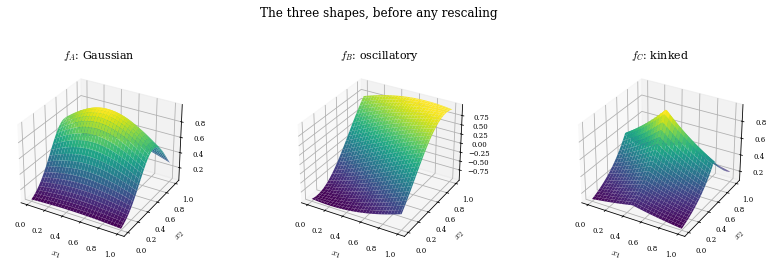

f_A: range [+0.049, +1.000],  mean |f| = 0.550
f_B: range [-1.000, +1.000],  mean |f| = 0.576
f_C: range [+0.106, +0.976],  mean |f| = 0.413


In [3]:
# ----------------------------------------------------------------
# The three target shapes
# ----------------------------------------------------------------
d = 2

def genz_gaussian(X, c, w):    return np.exp(-np.sum(c**2 * (X - w)**2, axis=1))
def genz_oscillatory(X, c, w): return np.cos(2.0 * np.pi * w[0] + X @ c)
def genz_continuous(X, c, w):  return np.exp(-np.sum(c * np.abs(X - w), axis=1))

_rng    = np.random.RandomState(7)
c_param = _rng.uniform(1.0, 3.0, size=d)
w_param = _rng.uniform(0.2, 0.8, size=d)

SHAPES = [lambda X: genz_gaussian(X, c_param, w_param),
          lambda X: genz_oscillatory(X, c_param, w_param),
          lambda X: genz_continuous(X, c_param, w_param)]
NAMES  = ["A (Gaussian)", "B (oscillatory)", "C (kinked)"]

# The one knob.
SCALES_FLAT  = np.array([1.0, 1.0, 1.0])          # control: all three at O(1)
SCALES_SPLIT = np.array([1.0, 1.0e2, 1.0e4])      # the realistic case

def targets(X, scales):
    return [(scales[k] * SHAPES[k](X)).astype(np.float32) for k in range(3)]

# Data
n_train, n_test = 1000, 2000
X_train = np.random.uniform(0, 1, (n_train, d)).astype(np.float32)
X_test  = np.random.uniform(0, 1, (n_test,  d)).astype(np.float32)

grid_n = 60
_t = np.linspace(0, 1, grid_n)
X1, X2 = np.meshgrid(_t, _t)
X_grid = np.column_stack([X1.ravel(), X2.ravel()]).astype(np.float32)

fig, axes = plt.subplots(1, 3, figsize=(12, 3.4), subplot_kw={"projection": "3d"})
for ax, name, shape in zip(axes, NAMES, SHAPES):
    ax.plot_surface(X1, X2, shape(X_grid).reshape(grid_n, grid_n),
                    cmap="viridis", edgecolor="none", rcount=50, ccount=50)
    ax.set_title(f"$f_{name[0]}$: {name[3:-1]}", fontsize=11)
    ax.set_xlabel("$x_1$", fontsize=9); ax.set_ylabel("$x_2$", fontsize=9)
    ax.tick_params(labelsize=7)
fig.suptitle("The three shapes, before any rescaling", y=1.03)
fig.tight_layout(); plt.show()

for k, name in enumerate(NAMES):
    y = SHAPES[k](X_grid)
    print(f"f_{name[0]}: range [{y.min():+.3f}, {y.max():+.3f}],  mean |f| = {np.abs(y).mean():.3f}")

In [4]:
# ----------------------------------------------------------------
# Training budget
# ----------------------------------------------------------------
# smoke      : 150 epochs, ~30 s per run   (sanity check)
# teaching   : 500 epochs, ~1 min per run  (the numbers quoted in the slides)
# production : 1500 epochs, ~3 min per run (regenerates the slide figures)
EPOCHS  = {"smoke": 150, "teaching": 500, "production": 1500}[RUN_MODE]
T_SWEEP = {"smoke": [0.1, 1.0], "teaching": [0.01, 0.1, 1.0, 10.0],
           "production": [0.01, 0.1, 1.0, 10.0]}[RUN_MODE]
# Single runs of this experiment are noisy: the same rule can land anywhere in a
# factor-of-three band depending on the draw. Every comparison below is therefore
# reported as a median over several seeds, with the range, exactly as the slides do.
SEEDS   = {"smoke": [0], "teaching": [0, 1, 2], "production": [0, 1, 2, 3, 4]}[RUN_MODE]
print(f"{EPOCHS} epochs per run; seeds {SEEDS}; temperature sweep over {T_SWEEP}")

500 epochs per run; seeds [0, 1, 2]; temperature sweep over [0.01, 0.1, 1.0, 10.0]


In [5]:
# ----------------------------------------------------------------
# Model, training loop, and the scale-free score
# ----------------------------------------------------------------

def build_model(n_layers=3, n_units=64, activation="relu"):
    """Shared trunk, three linear heads -- one per residual family."""
    inp = keras.Input(shape=(d,))
    x = inp
    for _ in range(n_layers):
        x = layers.Dense(n_units, activation=activation)(x)
    return keras.Model(inp, [layers.Dense(1, name=f"head_{c}")(x) for c in "ABC"])


def train(weight_fn, scales, epochs=None, seed=SEED, lr=1e-3, batch_size=64):
    """Train the three-head model under a weighting rule.

    weight_fn(losses, prev_losses, init_losses, prev_weights, epoch) -> [w_A, w_B, w_C]
    is called once per epoch with the epoch-average component losses.
    """
    epochs = EPOCHS if epochs is None else epochs
    # set_random_seed reseeds python, numpy and tf together, and clearing the
    # backend drops op-level state that tf.random.set_seed alone leaves behind.
    # Without this, two identical calls to train() return different numbers.
    keras.backend.clear_session()
    tf.keras.utils.set_random_seed(seed)

    model = build_model()
    opt   = keras.optimizers.Adam(lr)
    y_tr  = targets(X_train, scales)

    # The weights enter the graph as a variable, so the compiled step is reused.
    w_var = tf.Variable([1.0, 1.0, 1.0], dtype=tf.float32)
    X_tf  = tf.constant(X_train)
    Y_tf  = [tf.constant(y.reshape(-1, 1)) for y in y_tr]

    @tf.function
    def step(xb, ya, yb, yc):
        with tf.GradientTape() as tape:
            pa, pb, pc = model(xb, training=True)
            la = tf.reduce_mean(tf.square(ya - pa))
            lb = tf.reduce_mean(tf.square(yb - pb))
            lc = tf.reduce_mean(tf.square(yc - pc))
            total = w_var[0] * la + w_var[1] * lb + w_var[2] * lc
        opt.apply_gradients(zip(tape.gradient(total, model.trainable_variables),
                                model.trainable_variables))
        return la, lb, lc

    n_batches = n_train // batch_size
    weights, init_losses, prev_losses = [1.0, 1.0, 1.0], None, None
    hist = {"loss": [], "weight": []}

    for epoch in range(epochs):
        w_var.assign(np.asarray(weights, dtype=np.float32))
        idx  = np.random.permutation(n_train)
        acc  = np.zeros(3)
        for b in range(n_batches):
            j = tf.constant(idx[b*batch_size:(b+1)*batch_size], dtype=tf.int32)
            ls = step(tf.gather(X_tf, j), *[tf.gather(Y, j) for Y in Y_tf])
            acc += np.array([float(v) for v in ls]) / n_batches
        if init_losses is None:
            init_losses, prev_losses = list(acc), list(acc)
        weights    = weight_fn(list(acc), prev_losses, init_losses, weights, epoch)
        prev_losses = list(acc)
        hist["loss"].append(acc.copy())
        hist["weight"].append(list(weights))

    hist["loss"]   = np.array(hist["loss"])
    hist["weight"] = np.array(hist["weight"])
    return model, hist


def relative_errors(model, undo_scale=(1.0, 1.0, 1.0)):
    """Mean |error| for each component, divided by that component's own scale.

    Dividing by the scale is what makes the three components comparable: a raw
    MAE of 30 is excellent for f_C and catastrophic for f_A. It is also exactly
    the non-dimensionalization of Section 4, applied to the score rather than to
    the loss, and it is the definition the slides use.
    `undo_scale` multiplies the predictions back up when the network was trained
    on rescaled targets.
    """
    preds = model(tf.constant(X_test), training=False)
    out = []
    for k in range(3):
        y_true = (SCALES_SPLIT[k] * SHAPES[k](X_test)).astype(np.float32)
        p      = preds[k].numpy().ravel() * undo_scale[k]
        out.append(float(np.abs(p - y_true).mean() / SCALES_SPLIT[k]))
    return np.array(out)


def report(tag, rel):
    print(f"{tag:<24s}  " + "   ".join(f"rel_{c} = {v:7.4f}" for c, v in zip("ABC", rel))
          + f"   |   total = {rel.sum():.4f}")

RESULTS = {}   # tag -> relative-error vector

---
## 2. Control: the same three shapes, all at scale 1

Before blaming the scales we have to rule out the alternative explanation: perhaps one
of these three functions is simply hard to fit, or three tasks are too many for one
trunk. So we first train with **equal weights on targets that all live at $O(1)$**.

If all three come out accurate, the shapes and the architecture are exonerated, and
whatever goes wrong in Section 3 is the scales.

In [6]:
def equal_weights(losses, prev_losses, init_losses, prev_weights, epoch):
    return [1.0, 1.0, 1.0]

t0 = time.time()
model_flat, hist_flat = train(equal_weights, SCALES_FLAT)
print(f"trained in {time.time()-t0:.0f}s\n")

# On the flat run the network sees unscaled targets, so scale the predictions
# back up before scoring against the same yardstick as every other run.
rel_flat = relative_errors(model_flat, undo_scale=SCALES_SPLIT)
RESULTS["control: equal weights, all scales 1"] = rel_flat
report("control (flat scales)", rel_flat)
print(f"\nWorst component: {100*rel_flat.max():.1f}% relative error. All three are learned.")
print("The shapes are fine, the trunk is big enough, and three heads are not too many.")

2026-08-19 07:33:44.462488: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


trained in 10s

control (flat scales)     rel_A =  0.0030   rel_B =  0.0022   rel_C =  0.0031   |   total = 0.0083

Worst component: 0.3% relative error. All three are learned.
The shapes are fine, the trunk is big enough, and three heads are not too many.


---
## 3. The scale problem

Now the *only* change: multiply the targets by $10^0$, $10^2$, $10^4$. The shapes,
the data, the network, the optimizer and the seed are identical to Section 2.

With equal weights the total loss is dominated by $\mathcal{L}_C \sim 10^8$, so
$\partial J/\partial\theta \approx \partial \mathcal{L}_C/\partial\theta$ and the
network effectively solves a single-task problem.

In [7]:
t0 = time.time()
model_equal, hist_equal = train(equal_weights, SCALES_SPLIT)
print(f"trained in {time.time()-t0:.0f}s\n")

rel_equal = relative_errors(model_equal)
RESULTS["equal weights"] = rel_equal
report("equal weights", rel_equal)
print()
report("control (flat scales)", rel_flat)
print(f"\nSame problem, same network, only the units changed:"
      f" the total relative error grew by {rel_equal.sum()/rel_flat.sum():.0f}x.")

trained in 10s

equal weights             rel_A =  0.1771   rel_B =  0.5399   rel_C =  0.1162   |   total = 0.8332

control (flat scales)     rel_A =  0.0030   rel_B =  0.0022   rel_C =  0.0031   |   total = 0.0083

Same problem, same network, only the units changed: the total relative error grew by 101x.


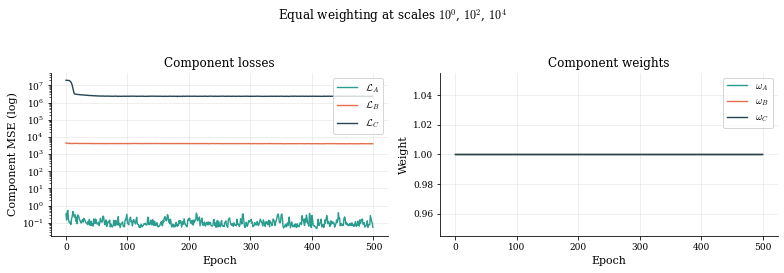

The three MSE curves never meet: they are separated by the square of the scale
ratio, which is exactly what the optimizer sees.


In [8]:
# ----------------------------------------------------------------
# Diagnostic plot: component losses and component weights
# ----------------------------------------------------------------

def plot_run(hist, title, savename=None):
    fig, axes = plt.subplots(1, 2, figsize=(11, 3.6))
    for k, c in enumerate("ABC"):
        axes[0].semilogy(hist["loss"][:, k], color=C[c], lw=1.4,
                         label=rf"$\mathcal{{L}}_{c}$")
        axes[1].plot(hist["weight"][:, k], color=C[c], lw=1.4,
                     label=rf"$\omega_{c}$")
    axes[0].set_xlabel("Epoch"); axes[0].set_ylabel("Component MSE (log)")
    axes[0].set_title("Component losses"); axes[0].legend()
    axes[1].set_xlabel("Epoch"); axes[1].set_ylabel("Weight")
    axes[1].set_title("Component weights"); axes[1].legend()
    fig.suptitle(title, y=1.04)
    fig.tight_layout()
    if SAVE_FIGS and savename:
        FIG_DIR.mkdir(parents=True, exist_ok=True)
        fig.savefig(FIG_DIR / f"{savename}.pdf", bbox_inches="tight")
    plt.show()

plot_run(hist_equal, "Equal weighting at scales $10^0$, $10^2$, $10^4$",
         savename="loss_norm_equal_weights")
print("The three MSE curves never meet: they are separated by the square of the scale")
print("ratio, which is exactly what the optimizer sees.")

---
## 4. Fix 1: non-dimensionalize, then weight equally

Every residual has a natural scale: consumption, output, a marginal utility. Dividing
each residual by that scale before it enters the loss costs nothing and removes the
problem at the source. Here we simply divide each target by its own scale, train with
equal weights, and multiply the predictions back afterwards.

This is the boring fix, and it is the one to do first.

In [9]:
# Dividing every target by its own scale gives back exactly the Section 2 setup,
# so there is nothing left to train: the control run IS the non-dimensionalized run.
# That equivalence is the whole point, and it costs one line instead of one training.
model_norm, hist_norm, rel_norm = model_flat, hist_flat, rel_flat
RESULTS["normalized residuals"] = rel_norm

report("normalized residuals", rel_norm)
report("equal weights", rel_equal)
print(f"\nFactor {rel_equal.sum()/rel_norm.sum():.0f}x better on the total relative error,")
print("from a change of units and no new hyperparameter.")

normalized residuals      rel_A =  0.0030   rel_B =  0.0022   rel_C =  0.0031   |   total = 0.0083
equal weights             rel_A =  0.1771   rel_B =  0.5399   rel_C =  0.1162   |   total = 0.8332

Factor 101x better on the total relative error,
from a change of units and no new hyperparameter.


---
## 5. Fix 2: inverse-loss weighting

When the scales are not known in advance, the obvious adaptive rule is to weight each
component by the inverse of its current magnitude,

$$\bar{\mathcal{L}}_k^{(m)} = \beta\,\bar{\mathcal{L}}_k^{(m-1)} + (1-\beta)\,\mathcal{L}_k^{(m)},
\qquad
\omega_k^{(m)} = \frac{1}{\bar{\mathcal{L}}_k^{(m)} + 10^{-8}},$$

normalized so that $\sum_k \omega_k = M$. Watch what that normalization does when the
losses differ by $10^8$.

In [10]:
def make_inverse_loss(beta=0.99, eps=1e-8):
    ema = [None, None, None]
    def weights(losses, prev_losses, init_losses, prev_weights, epoch):
        for k in range(3):
            ema[k] = losses[k] if ema[k] is None else beta*ema[k] + (1-beta)*losses[k]
        raw = [1.0/(ema[k] + eps) for k in range(3)]
        s = sum(raw)
        return [3.0*r/s for r in raw]
    return weights

t0 = time.time()
model_inv, hist_inv = train(make_inverse_loss(), SCALES_SPLIT)
print(f"trained in {time.time()-t0:.0f}s\n")

rel_inv = relative_errors(model_inv)
RESULTS["inverse-loss weighting"] = rel_inv
report("inverse-loss weighting", rel_inv)
print("\nFinal weights: " + ", ".join(f"w_{c} = {v:.3e}"
      for c, v in zip("ABC", hist_inv["weight"][-1])))
print("\nThe constraint sum_k w_k = M plus a 1e8 spread in the losses drives w_B and w_C")
print("to numerical zero: the rule solves f_A and abandons the other two. That is the")
print("mirror image of equal weighting, not a fix.")

trained in 12s

inverse-loss weighting    rel_A =  0.0082   rel_B =  0.0329   rel_C =  0.4070   |   total = 0.4481

Final weights: w_A = 3.000e+00, w_B = 1.607e-05, w_C = 4.055e-10

The constraint sum_k w_k = M plus a 1e8 spread in the losses drives w_B and w_C
to numerical zero: the rule solves f_A and abandons the other two. That is the
mirror image of equal weighting, not a fix.


---
## 6. Fix 3: ReLoBRaLo, and a bound worth knowing

ReLoBRaLo (Bischof & Kraus, 2021) weights by **relative progress** rather than by
level. At optimizer step $m$,

$$\kappa_{k,s}^{(m)} = \frac{\mathcal{L}_k^{(m)}}{T\,\mathcal{L}_k^{(m-1)}},
\qquad
\kappa_{k,b}^{(m)} = \frac{\mathcal{L}_k^{(m)}}{T\,\mathcal{L}_k^{(0)}},$$

$$\omega_k^{(m)} = \alpha_{\mathrm{lb}}\Bigl[\rho_{\mathrm{lb}}\,\omega_k^{(m-1)}
   + (1-\rho_{\mathrm{lb}})\,M\operatorname{softmax}_k(\kappa_{\cdot,b}^{(m)})\Bigr]
   + (1-\alpha_{\mathrm{lb}})\,M\operatorname{softmax}_k(\kappa_{\cdot,s}^{(m)}).$$

Before running it, look at what the softmax can produce. For any two components,

$$\frac{\hat\omega_j}{\hat\omega_k} = \exp\!\bigl((\kappa_j - \kappa_k)/T\bigr).$$

The step-wise ratios $\kappa_{k,s}$ are ratios of **consecutive** losses, so they sit
near $1$ for every component, whatever the scale; the baseline ratios $\kappa_{k,b}$
lie in $[0, 1]$. With $T = 1$ the achievable spread in the weights is therefore about
$e^1 \approx 2.7$.

A factor of $2.7$ against a scale gap of $10^4$. The prediction is that ReLoBRaLo
leaves this problem essentially untouched — not because the implementation is wrong,
but because relative balancing is **not** what a scale mismatch needs.

trained in 10s

ReLoBRaLo (T=1)           rel_A =  0.1769   rel_B =  0.5395   rel_C =  0.1162   |   total = 0.8326
equal weights             rel_A =  0.1771   rel_B =  0.5399   rel_C =  0.1162   |   total = 0.8332

Weight trajectory:
  epoch     0: [1.000, 1.000, 1.000]
  epoch   124: [0.993, 1.047, 0.960]
  epoch   249: [0.984, 1.088, 0.928]
  epoch   499: [0.975, 1.143, 0.883]

Largest weight ratio reached: 1.29x (the softmax bound is about 2.7x at T=1). Needed to close the gap: 1e4 x.
Total relative error, ReLoBRaLo vs plain equal weighting: 0.833 vs 0.833 -- 0% apart, against the 101x that non-dimensionalization delivered.


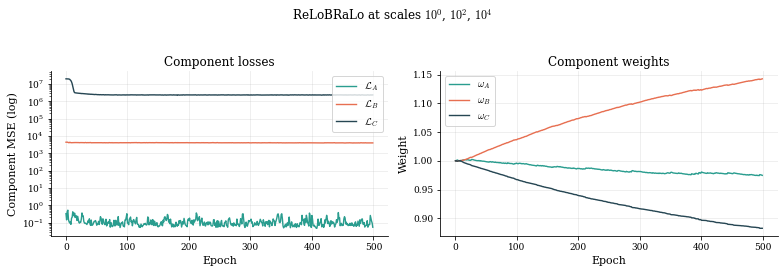

In [11]:
def make_relobralo(T=1.0, alpha_lb=0.999, rho_lb=0.999):
    """Deterministic classroom version: the original draws rho_lb ~ Bernoulli."""
    def weights(losses, prev_losses, init_losses, prev_weights, epoch):
        eps = 1e-12
        k_step = np.array([losses[k] / (T*prev_losses[k] + eps) for k in range(3)])
        k_base = np.array([losses[k] / (T*init_losses[k] + eps) for k in range(3)])
        e_s = np.exp(k_step - k_step.max()); w_step = 3.0 * e_s / e_s.sum()
        e_b = np.exp(k_base - k_base.max()); w_base = 3.0 * e_b / e_b.sum()
        return [alpha_lb*(rho_lb*prev_weights[k] + (1-rho_lb)*w_base[k])
                + (1-alpha_lb)*w_step[k] for k in range(3)]
    return weights

t0 = time.time()
model_relo, hist_relo = train(make_relobralo(T=1.0), SCALES_SPLIT)
print(f"trained in {time.time()-t0:.0f}s\n")

rel_relo = relative_errors(model_relo)
RESULTS["ReLoBRaLo (T=1)"] = rel_relo
report("ReLoBRaLo (T=1)", rel_relo)
report("equal weights", rel_equal)

w = hist_relo["weight"]
print("\nWeight trajectory:")
for frac in (0.0, 0.25, 0.5, 1.0):
    i = min(int(frac*(len(w)-1)), len(w)-1)
    print(f"  epoch {i:>5d}: [" + ", ".join(f"{v:.3f}" for v in w[i]) + "]")
print(f"\nLargest weight ratio reached: {w[-1].max()/w[-1].min():.2f}x "
      f"(the softmax bound is about {np.e:.1f}x at T=1). Needed to close the gap: 1e4 x.")
print(f"Total relative error, ReLoBRaLo vs plain equal weighting: "
      f"{rel_relo.sum():.3f} vs {rel_equal.sum():.3f} "
      f"-- {100*abs(rel_relo.sum()-rel_equal.sum())/rel_equal.sum():.0f}% apart, against the"
      f" {rel_equal.sum()/rel_norm.sum():.0f}x that non-dimensionalization delivered.")

plot_run(hist_relo, "ReLoBRaLo at scales $10^0$, $10^2$, $10^4$",
         savename="loss_norm_relobralo_weights")

### So what is ReLoBRaLo for?

For the case it was designed for: components that are **already on comparable scales**
but converge at different *rates* — a PDE residual that drops quickly while a boundary
residual stalls. There, a factor of $2.7$ is exactly the right amount of authority, and
the relative-progress signal is informative.

Use it **after** non-dimensionalizing, not instead of it. That is also what the
original paper does: PINN losses are non-dimensionalized before ReLoBRaLo is applied.

  seed 0 done (41s)


  seed 1 done (82s)


  seed 2 done (125s)

rule                        median       min       max   (n = 3 seeds)
--------------------------------------------------------------
equal weights               0.8607    0.8332    0.9241
inverse-loss                0.4481    0.4178    0.6090
ReLoBRaLo (T=1)             0.8610    0.8326    0.9327
normalized residuals        0.0115    0.0083    0.0181


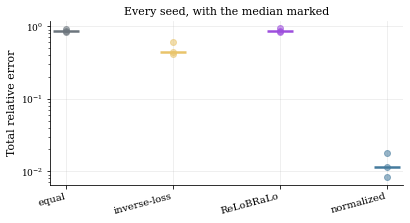


The three weighting rules overlap; only non-dimensionalization separates.


In [12]:
# ----------------------------------------------------------------
# All four methods, several seeds, on one scale-free axis
# ----------------------------------------------------------------
# The single runs above are illustrations. For the ranking we need the spread:
# one draw of any of these rules can land anywhere in a factor-of-three band.

RULES = {
    "equal weights":        (equal_weights,          SCALES_SPLIT, (1.0, 1.0, 1.0)),
    "inverse-loss":         (None,                   SCALES_SPLIT, (1.0, 1.0, 1.0)),
    "ReLoBRaLo (T=1)":      (None,                   SCALES_SPLIT, (1.0, 1.0, 1.0)),
    "normalized residuals": (equal_weights,          SCALES_FLAT,  tuple(SCALES_SPLIT)),
}

def rule_fn(name):
    if name == "inverse-loss":    return make_inverse_loss()
    if name == "ReLoBRaLo (T=1)": return make_relobralo(T=1.0)
    return equal_weights

totals = {name: [] for name in RULES}
t0 = time.time()
for sd in SEEDS:
    for name, (_, scales, undo) in RULES.items():
        m, _ = train(rule_fn(name), scales, seed=sd)
        totals[name].append(relative_errors(m, undo_scale=undo).sum())
    print(f"  seed {sd} done ({time.time()-t0:.0f}s)")

print(f"\n{'rule':<24s}  {'median':>8s}  {'min':>8s}  {'max':>8s}   (n = {len(SEEDS)} seeds)")
print("-" * 62)
for name in RULES:
    v = np.array(totals[name])
    print(f"{name:<24s}  {np.median(v):8.4f}  {v.min():8.4f}  {v.max():8.4f}")

order = list(RULES)
cols  = [M_COL["equal"], M_COL["inverse"], M_COL["relobralo"], M_COL["normalized"]]
fig, ax = plt.subplots(figsize=(5.8, 3.2))
for i, (name, c) in enumerate(zip(order, cols)):
    v = np.array(totals[name])
    ax.plot([i]*len(v), v, "o", color=c, ms=6, alpha=0.55)
    ax.plot([i], [np.median(v)], "_", color=c, ms=26, mew=2.5)
ax.set_yscale("log")
ax.set_xticks(range(len(order)))
ax.set_xticklabels(["equal", "inverse-loss", "ReLoBRaLo", "normalized"],
                   rotation=15, ha="right", fontsize=10)
ax.set_ylabel("Total relative error", fontsize=11)
ax.set_title("Every seed, with the median marked", fontsize=11)
fig.tight_layout()
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "loss_norm_method_comparison.pdf", bbox_inches="tight")
plt.show()

print("\nThe three weighting rules overlap; only non-dimensionalization separates.")

---
## 7. Sensitivity to the temperature $T$

$T$ sets how sharp the softmax is, so it sets how far the weights are allowed to
separate: the achievable ratio is $\exp(\Delta\kappa / T)$. Small $T$ buys authority
at the cost of winner-take-all behavior; large $T$ collapses to equal weighting.

The sweep below runs ReLoBRaLo on the mismatched-scale problem, so the honest reading
is: does *any* temperature rescue it?

T = 0.01    median  0.8624  [0.8333, 0.9774]   weight spread  2.52x   (31s)


T = 0.1     median  0.8572  [0.8318, 0.9832]   weight spread  2.45x   (63s)


T = 1       median  0.8610  [0.8326, 0.9327]   weight spread  1.29x   (95s)


T = 10      median  0.8608  [0.8331, 0.9247]   weight spread  1.03x   (127s)


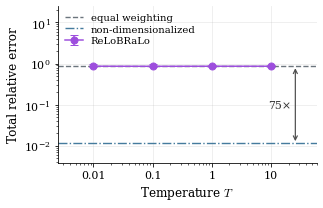


Every temperature stays within a factor of a few of equal weighting,
and all of them sit far above the non-dimensionalized level (0.0115).
The error bars are the point: single runs of this experiment are noisy,
so a one-seed sweep can suggest a winner that does not survive replication.


In [13]:
sweep = {}
t0 = time.time()
for T in T_SWEEP:
    vals, spreads = [], []
    for sd in SEEDS:
        m_T, h_T = train(make_relobralo(T=T), SCALES_SPLIT, seed=sd)
        vals.append(relative_errors(m_T).sum())
        spreads.append(h_T["weight"][-1].max() / h_T["weight"][-1].min())
    sweep[T] = {"vals": np.array(vals), "spread": float(np.median(spreads))}
    v = sweep[T]["vals"]
    print(f"T = {T:<6g}  median {np.median(v):7.4f}  [{v.min():.4f}, {v.max():.4f}]"
          f"   weight spread {sweep[T]['spread']:5.2f}x   ({time.time()-t0:.0f}s)")

# A bar chart would be the wrong encoding here: bar length measures distance from
# zero, and a log axis has no zero, so values within a factor of two of each other
# would render as identical full-height bars. What matters is where the points sit
# relative to the two reference levels, so plot them against those levels.
# The canvas is kept small: it is shown at ~4 cm on the slide, and a large figure
# would shrink the tick labels into illegibility.
Ts   = np.array(list(sweep), dtype=float)
med  = np.array([np.median(sweep[T]["vals"]) for T in sweep])
lo   = np.array([sweep[T]["vals"].min() for T in sweep])
hi   = np.array([sweep[T]["vals"].max() for T in sweep])
eq   = float(np.median(totals["equal weights"]))
nd   = float(np.median(totals["normalized residuals"]))

fig, ax = plt.subplots(figsize=(4.6, 3.0))
ax.axhline(eq, color=M_COL["equal"],      ls="--", lw=1.4, label="equal weighting")
ax.axhline(nd, color=M_COL["normalized"], ls="-.", lw=1.4, label="non-dimensionalized")
ax.errorbar(Ts, med, yerr=[med - lo, hi - med], fmt="o-", color=M_COL["relobralo"],
            ms=7, lw=1.5, capsize=4, zorder=3, label="ReLoBRaLo")

ax.set_xscale("log"); ax.set_yscale("log")
ax.set_ylim(min(nd, lo.min()) / 3.0, max(eq, hi.max()) * 25.0)
ax.set_xlim(Ts.min() / 4.0, Ts.max() * 6.0)
ax.set_xticks(Ts); ax.set_xticklabels([f"{t:g}" for t in Ts], fontsize=11)
ax.tick_params(axis="y", labelsize=11)
ax.set_xlabel("Temperature $T$", fontsize=12)
ax.set_ylabel("Total relative error", fontsize=12)
ax.legend(fontsize=10, loc="upper left", frameon=False,
          handlelength=1.8, borderpad=0.2, labelspacing=0.25)

xg = Ts.max() * 2.6
ax.annotate("", xy=(xg, eq), xytext=(xg, nd),
            arrowprops=dict(arrowstyle="<->", color="0.3", lw=1.2))
ax.annotate(f"{eq/nd:.0f}×", xy=(xg, (eq*nd)**0.5), xytext=(-4, 0),
            textcoords="offset points", fontsize=11, color="0.2",
            va="center", ha="right")
fig.tight_layout()
if SAVE_FIGS:
    FIG_DIR.mkdir(parents=True, exist_ok=True)
    fig.savefig(FIG_DIR / "loss_norm_T_sensitivity.pdf", bbox_inches="tight")
plt.show()

print(f"\nEvery temperature stays within a factor of a few of equal weighting,")
print(f"and all of them sit far above the non-dimensionalized level ({nd:.4f}).")
print("The error bars are the point: single runs of this experiment are noisy,")
print("so a one-seed sweep can suggest a winner that does not survive replication.")

---
## 8. What to remember

1. **Multi-component losses at different scales cause gradient dominance.** The control
   in Section 2 shows the shapes are learnable; only the units changed in Section 3.

2. **Non-dimensionalize first.** Dividing each residual by its own scale is free, has no
   hyperparameters, and on this testbed beats every adaptive scheme by two orders of
   magnitude. In a DEQN this means writing Euler errors in consumption units, budget
   residuals as a share of output, and so on.

3. **Inverse-loss weighting is not a scale fix.** Normalizing $\sum_k \omega_k = M$ across
   losses that span $10^8$ sends all but the smallest weight to zero.

4. **ReLoBRaLo balances progress, not magnitude.** Its softmax over loss *ratios* can
   only spread the weights by about $e^{1/T}$, so it cannot close a large scale gap by
   construction. Apply it after non-dimensionalization, where a factor of a few is the
   right amount of authority.

5. **Always monitor every component separately, in scale-free units.** A small total is
   not a certificate: it can hide a component that is entirely unlearned.

### Where this shows up in DEQNs

Euler residuals, budget constraints, market clearing and complementarity conditions all
carry different units. Exercise 3 of this session (notebook `02_03`) adds a squared
Fischer–Burmeister residual to a squared Euler residual, and the two arrive at very
different magnitudes — a textbook case for the recipe above.

### References

- Bischof, R., & Kraus, M. (2021). *Multi-objective loss balancing for physics-informed
  deep learning.* arXiv:2110.09813; published in **CMAME** 439, 117914 (2025).
- Heydari, A. A., Thompson, C. A., & Mehmood, A. (2019). *SoftAdapt.* arXiv:1912.12355.
- Chen, Z., Badrinarayanan, V., Lee, C.-Y., & Rabinovich, A. (2018). *GradNorm.* ICML.
- Wang, S., Teng, Y., & Perdikaris, P. (2021). *Understanding and mitigating gradient
  flow pathologies in physics-informed neural networks.* SIAM J. Sci. Comput. 43(5).